## UML Demo

This notebook demonstrates the `PhysComp.uml` module, which decomposes and reconstructs data

### Functions covered:
- `uml.decomp_data` — decompose and reconstruct data
- `uml.get_components` — find a set of single components of the decomposition
- `uml.scree_plot` — find and optionally plot the scree plot
- `uml.find_elbow` — find the elbow from the scree plot

In [3]:
## Needed imports for module
import hyperspy.api as hs
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional

## Simulation module for example data
import PhysComp.sim as sim

## Import actual uml module
import PhysComp.uml as uml

#### Simulating data to decompose, see the sim demo notebook for more information

In [4]:
simulated_dataset = sim.sim_dataset(30,30,360,100,100, filesave= True,save_path="Test.npy", seed=100) # Simulating data, see Sim notebook

### Decomp_data
#### This function takes a dataset given by a filepath and decomposes it into components using the given algorithm, then reconstructs it using a given number of components. If no given number of components, then the function will determine ideal components through Scree Plot elbow.

In [10]:
path = "Test.npy" #Filepath for dataset to decompose
algorithm = "SVD" # Chosen algorithm for decomposition
comps = 3 # Chosen number of components, if left blank will be calculated by scree plot
plotting = False # If true plots scree plot

sd = uml.decomp_data(path,algorithm, components=comps, plot=plotting)

Decomposition info:
  normalize_poissonian_noise=False
  algorithm=SVD
  output_dimension=None
  centre=None
Scree Plot: calculated 4 relevant components


### get_components
#### This function calculates a given component or set of components for a previously decomposed object. If plotting is enabled it wil

In [12]:
raw_data = hs.load("Test.npy")
data_hs_func = hs.signals.Signal1D(raw_data.data)
data_hs_func.decomposition(algorithm="SVD")

Decomposition info:
  normalize_poissonian_noise=False
  algorithm=SVD
  output_dimension=None
  centre=None


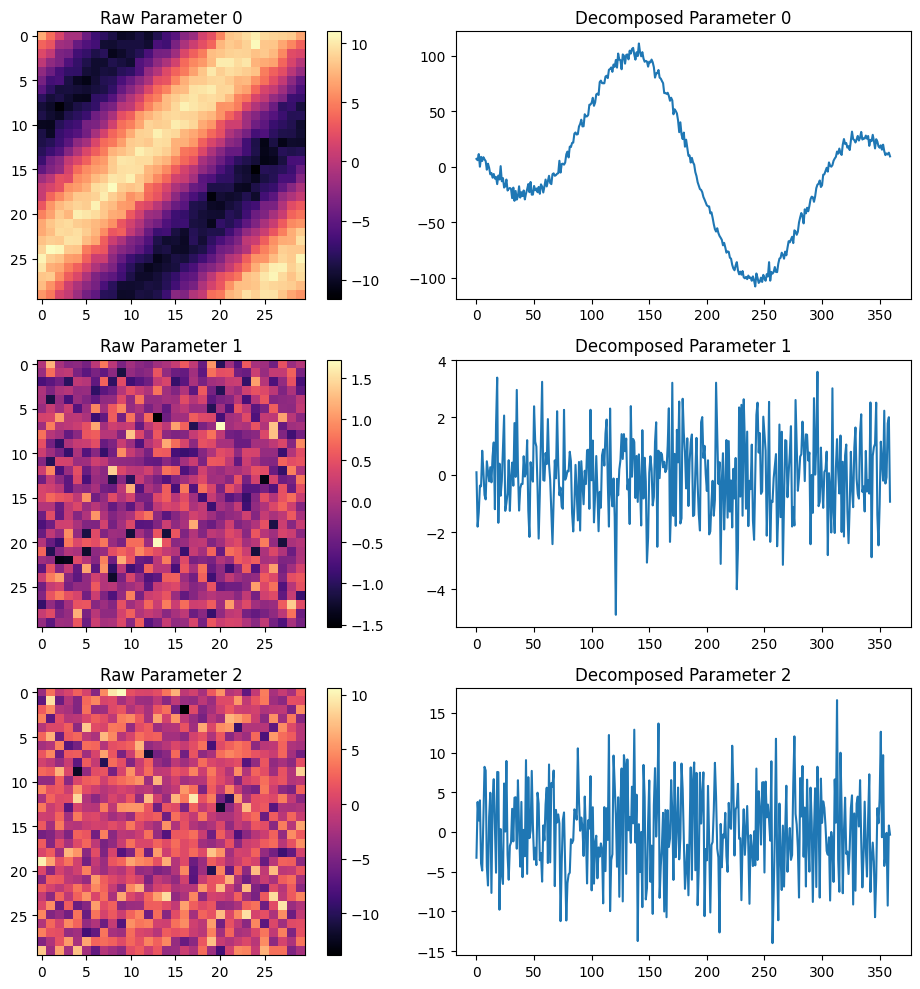

In [20]:
decomposed_obj = data_hs_func # Hyperspy decomposed object
comps = [1,10,100] # Chosen components, for this example we are showing component 1,10,100
plotting = True # If false just stores arrays no visualisation

components = uml.get_components(decomposed_obj,comps, plot = plotting)

### Scree_plot

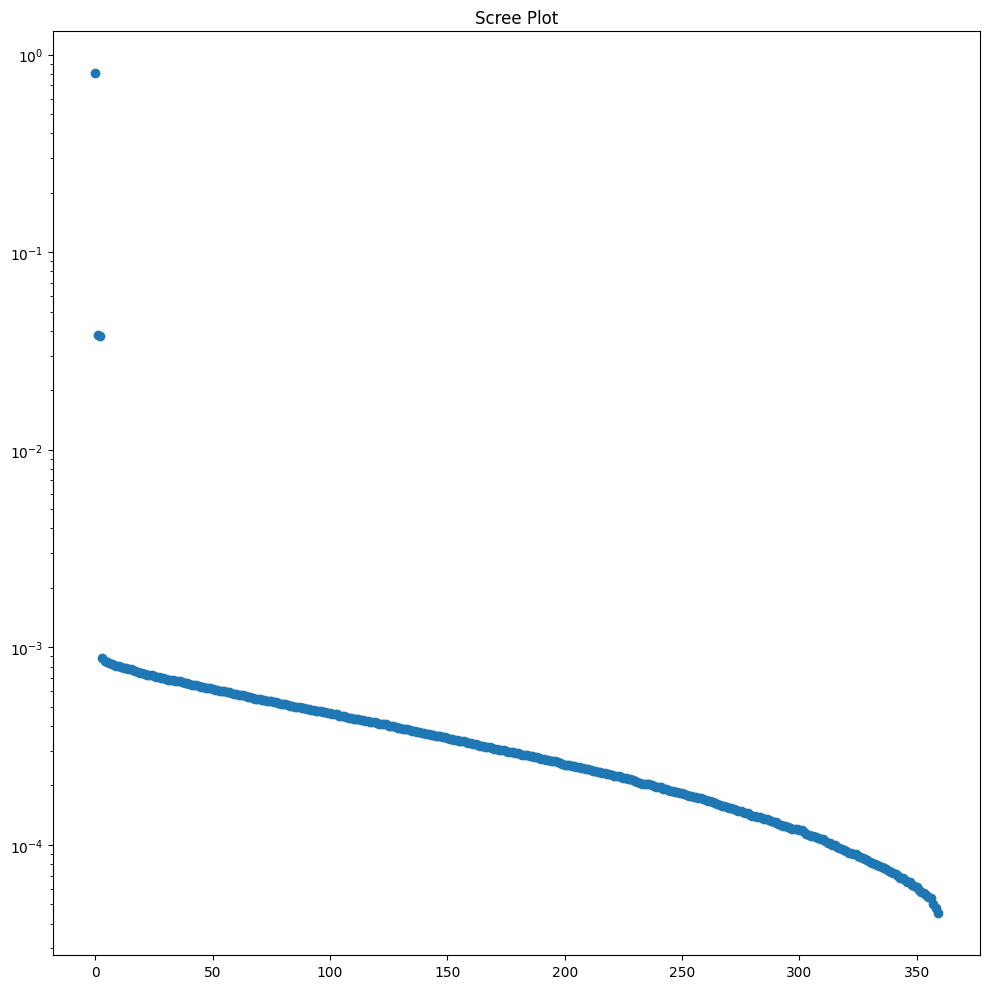

Scree Plot: calculated 4 relevant components


In [23]:
scree_plot = uml.scree_plot(data_hs_func,plot=True)

### Find_elbow

In [28]:
variance = data_hs_func.get_explained_variance_ratio().data
relavent_comps = uml.find_elbow(variance)
print(relavent_comps)

[1. 2. 3. 4.]
